# Frozen-CPU vs CUDA — isolating pedestal-update timing

`ClusterFinderFrozen` is a diagnostic twin of the serial `ClusterFinder`: **identical**
decision logic (negative skip, Test1, Test3, `value == max` store gate, edge handling,
rounding), differing in **exactly one** respect — *when* the pedestal is updated.

| finder | pedestal update |
|---|---|
| `ClusterFinder` | per-pixel, **during** the raster scan (scan-order dependent) |
| `ClusterFinderFrozen` | frozen snapshot for all decisions; **deferred** to frame end |
| `ClusterFinderCUDA` | frozen per frame; batch update at frame end |

`Frozen` and `CUDA` share the same update *model*.

In [1]:
import sys; sys.path.append('/home/ferjao_k/aare/build')

from pathlib import Path
import numpy as np
import time

from aare import File, ClusterFinder, ClusterFinderFrozen, ClusterFinderCUDA
from helper import (centers, only_sets, train_pedestal,
                    compare_finders, print_comparison, plot_spectra,
                    scan_mismatches, plot_masked_mismatch, walkthrough)

In [2]:
base = Path('/mnt/sls_det_storage/moench_data/2603_MaxIVBeamtime/2026032408/process/xrf/')
f = File(base / 'Cu_factor_10_data_master_0.json')
pd = File(base / 'Cu_factor_10_pedestal_master_0.json')

n_frames_pd  = 1000
N            = 20000
cluster_size = (3, 3)
rows, cols   = f.rows, f.cols
image_size   = (rows, cols)
capacity     = 50_000

N_STREAMS = 4     # single device pedestal -> apples-to-apples with the CPU finders
N_SIGMA   = 5
sx, sy = cluster_size
rx, ry = sx // 2, sy // 2
print(f'image {image_size}  pedestal {n_frames_pd}  data {N}  streams {N_STREAMS}')

image (400, 400)  pedestal 1000  data 20000  streams 4


In [3]:
cf_cpu = ClusterFinder(image_size, cluster_size, n_sigma=N_SIGMA, capacity=capacity)
cf_frozen = ClusterFinderFrozen(image_size, cluster_size, n_sigma=N_SIGMA, capacity=capacity)
cf_cuda = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                            max_clusters_per_frame=3000, n_streams=N_STREAMS)

In [4]:
# Train ALL three on the SAME pedestal frames, then load the data block.
t0 = time.perf_counter()
for _ in range(n_frames_pd):
    img = pd.read_frame().copy()
    cf_cpu.push_pedestal_frame(img)
    cf_frozen.push_pedestal_frame(img)
    cf_cuda.push_pedestal_frame(img)
print(f'pedestal train: {time.perf_counter()-t0:.2f}s')

f.seek(0)
data = f.read_n(N)
print('data:', data.shape, data.dtype)

pedestal train: 0.78s
data: (20000, 400, 400) uint16


## The three-way comparison
- All three finders now carry the **same** trained pedestal. 
- `compare_finders` runs each over the same sampled frames and reports exact (tol=0) pairwise centre mismatches.

In [5]:
SCAN = 20000   # frames sampled across `data` (set to len(data) for the full block)

totals, pairs, nscan, hists = compare_finders(
    # {'frozen': cf_frozen, 'cuda': cf_cuda}, data, scan_count=SCAN)
    {'cpu': cf_cpu, 'frozen': cf_frozen, 'cuda': cf_cuda}, data, scan_count=SCAN)
print_comparison(totals, pairs, nscan)

Scanned 20000 frames

Total clusters per finder:
  cpu                46,478,554
  frozen             46,478,563
  cuda               46,478,563

Pairwise exact mismatches (tol=0):
  pair                             A-only     B-only      total
  cpu vs frozen                        13         22         35  (0.0001%)
  cpu vs cuda                          13         22         35  (0.0001%)
  frozen vs cuda                        0          0          0  (0.0000%)


**Reading the table.** If `frozen vs cuda` collapses to ~0 while `cpu vs cuda` and
`frozen vs cpu` are comparable and non-trivial, pedestal-update *timing* is the proven
cause. A small non-zero `frozen vs cuda` residual would be a genuine surprise (FP corner,
edge pixel, or the multi-stream path) worth chasing — not expected background.

## Cluster-energy spectra

The three finders' cluster-energy distributions, accumulated in the same compare pass
(no extra scan). They should overlap almost perfectly; the ratio panel (each vs `cpu`)
makes any per-bin divergence — e.g. the `frozen vs cuda` residual — visible.

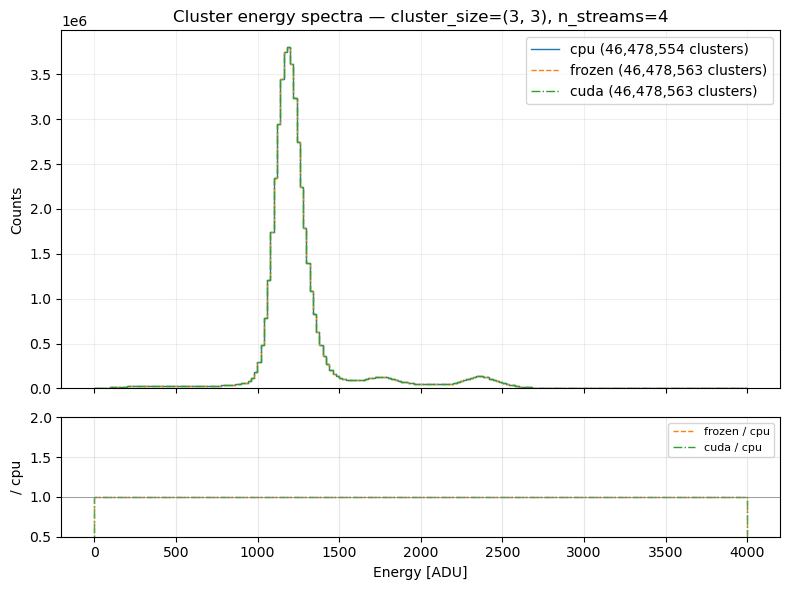

In [6]:
fig = plot_spectra(hists, totals,
                   title=f'Cluster energy spectra — cluster_size={cluster_size}, n_streams={N_STREAMS}')

## Eyeball any residual `frozen vs cuda` mismatches

Fresh finders, retrained identically, then the masked side-by-side view of the worst
residual frames. If the table showed 0, this should find nothing to plot.

In [7]:
cf_frozen2 = ClusterFinderFrozen(image_size, cluster_size, n_sigma=N_SIGMA, capacity=capacity)
cf_cuda2   = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                               max_clusters_per_frame=3000, n_streams=N_STREAMS)
train_pedestal([cf_frozen2, cf_cuda2], f, n_frames_pd, seek=0)

# scan_mismatches(a, b, ...) snapshots a.pedestal/noise (host) and b.device_*(0).
show, res = scan_mismatches(cf_frozen2, cf_cuda2, data, rx, ry,
                            scan_count=SCAN, n_show=8, tol=0)
print('frozen-only:', res['cpu_only'], ' cuda-only:', res['cu_only'], ' frames shown:', len(show))
if show:
    plot_masked_mismatch(show, data, rx, ry, rows, cols, zoom=30, show_vals=True)

frozen-only: 0  cuda-only: 0  frames shown: 0


## Walkthrough of the surviving mismatch

Manual Test1/Test3 recompute of the strongest residual cluster in `show`, under each
finder's decision-time snapshot pedestal.

In [8]:
# Dissect the surviving frozen-vs-cuda residual.
# Recomputes Test1/Test3 under each finder's decision-time snapshot pedestal, so the
# lone mismatched cluster is fully explained (which test flips, and the pedestal gap).
walkthrough(show, data, rx, ry, rows, cols, N_SIGMA, pick=0, labels=('frozen', 'cuda'))

No residual mismatches to walk through.
